# EigenDecomposition Visualization

## Plotting the Eigendecomposition A = Q * Λ * Q⁻¹ with matplotlib

### Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Define the Matrix and Perform Eigendecomposition

In [2]:
A = np.array([[2, 1], [1, 2]])

eigenvalues, U = np.linalg.eig(A)
Lambda = np.diag(eigenvalues)
U_inv = np.linalg.inv(U)  # U^-1

print(f"Matrix A:\n{A}\n")
print(f"Eigenvalues: {eigenvalues}\n")
print(f"Eigenvectors (U):\n{U}\n")
print(f"Diagonal Matrix (Lambda):\n{Lambda}\n")
print(f"Inverse of U (U^-1):\n{U_inv}")

Matrix A:
[[2 1]
 [1 2]]

Eigenvalues: [3. 1.]

Eigenvectors (U):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Diagonal Matrix (Lambda):
[[3. 0.]
 [0. 1.]]

Inverse of U (U^-1):
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


### Define a Unit Square

In [3]:
square = np.array([[-0.5, -0.5, 0.5, 0.5, -0.5], [-0.5, 0.5, 0.5, -0.5, -0.5]])

print(f"Unit Square:\n{square}")

Unit Square:
[[-0.5 -0.5  0.5  0.5 -0.5]
 [-0.5  0.5  0.5 -0.5 -0.5]]


### Transform the Square Using Eigendecomposition

In [4]:
square_U = U @ square  # U first
square_Lambda = Lambda @ square_U  # scaling eigenvectors
square_U_inv = U_inv @ square_Lambda  # U^-1

basis_vectors = np.array([[0.5, 0], [0, 0.5]])  # from [1, 0] and [0, 1] to half

basis_U = U @ basis_vectors  # Apply U first
basis_Lambda = Lambda @ basis_U  # Apply Lambda
basis_U_inv = U_inv @ basis_Lambda  # Apply U^-1

print(f"Transformed Square after U:\n{square_U}\n")
print(f"Transformed Square Scaling(Lambda):\n{square_Lambda}\n")
print(f"Transformed Square after U^-1:\n{square_U_inv}\n")
print(f"Basis Vectors Original:\n{basis_vectors}\n")
print(f"Basis Vectors after U:\n{basis_U}\n")
print(f"Basis Vectors after Lambda:\n{basis_Lambda}\n")
print(f"Basis Vectors after U^-1:\n{basis_U_inv}\n")

Transformed Square after U:
[[ 0.         -0.70710678  0.          0.70710678  0.        ]
 [-0.70710678  0.          0.70710678  0.         -0.70710678]]

Transformed Square Scaling(Lambda):
[[ 0.         -2.12132034  0.          2.12132034  0.        ]
 [-0.70710678  0.          0.70710678  0.         -0.70710678]]

Transformed Square after U^-1:
[[-0.5 -1.5  0.5  1.5 -0.5]
 [-0.5  1.5  0.5 -1.5 -0.5]]

Basis Vectors Original:
[[0.5 0. ]
 [0.  0.5]]

Basis Vectors after U:
[[ 0.35355339 -0.35355339]
 [ 0.35355339  0.35355339]]

Basis Vectors after Lambda:
[[ 1.06066017 -1.06066017]
 [ 0.35355339  0.35355339]]

Basis Vectors after U^-1:
[[ 1.  -0.5]
 [-0.5  1. ]]



### Define the Plotting Function

In [5]:
def plot_basis(ax, title, shape, vectors, color1="blue", color2="red"):
    ax.plot(shape[0], shape[1], color="gray", alpha=0.5)
    ax.quiver(0, 0, vectors[0, 0], vectors[1, 0], color=color1, angles='xy', scale_units='xy', scale=1)
    ax.quiver(0, 0, vectors[0, 1], vectors[1, 1], color=color2, angles='xy', scale_units='xy', scale=1)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(title, fontsize=30)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, linestyle="--", alpha=0.5)

### Plot the Transformations

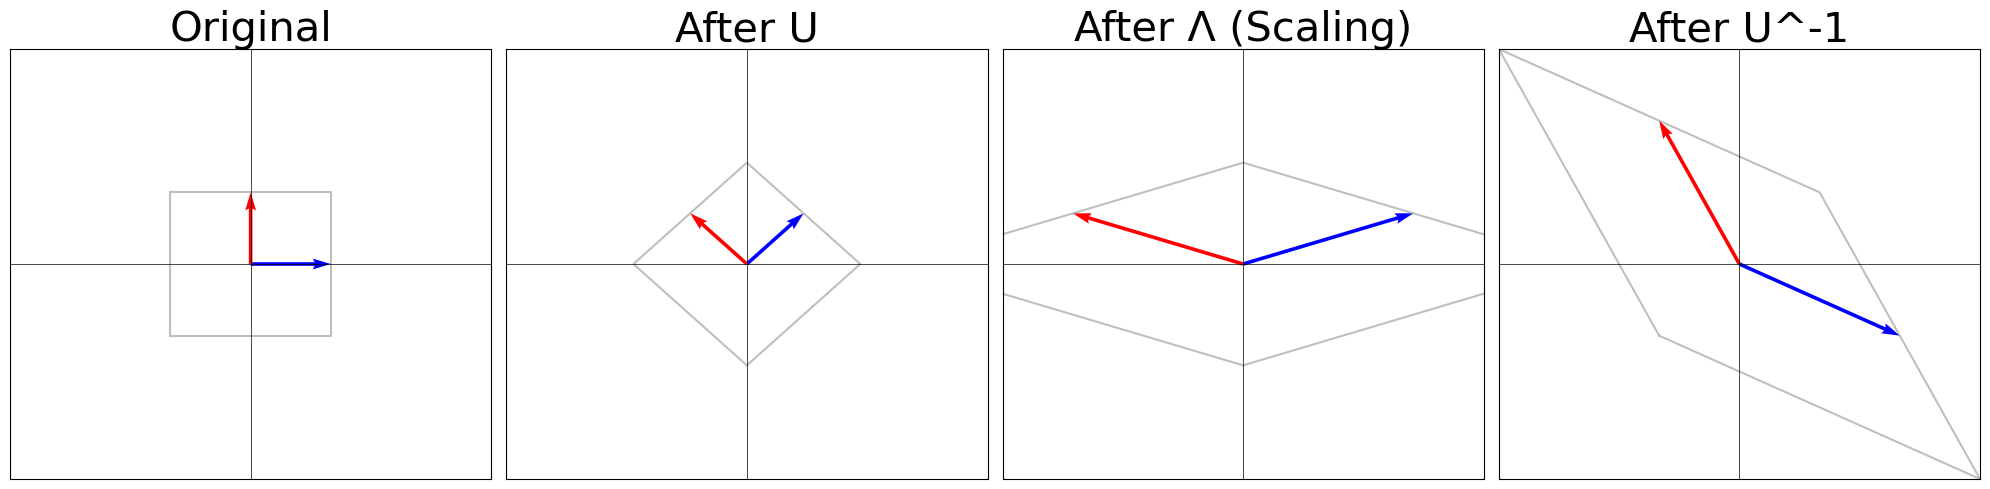

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# First Original basis and square
plot_basis(axes[0], "Original", square, basis_vectors)

# Second Applying U
plot_basis(axes[1], "After U", square_U, basis_U)

# Third Scaling eigenvectors
plot_basis(axes[2], "After Λ (Scaling)", square_Lambda, basis_Lambda)

# Fourth Apply U^-1 (Transforming back)
plot_basis(axes[3], "After U^-1", square_U_inv, basis_U_inv)

plt.tight_layout()
plt.show()